# Seattle Weather Project

## Introduction

Seattle is widely known for its rainy weather, but does it actually rain more in Seattle than in Boston? This project uses daily precipitation data from Seattle, WA and Boston, MA from January 1, 2018 to December 31, 2022 to compare precipitation between the two cities.

The analysis examines the amount and frequency of precipitation in each city. In particular, it compares daily, monthly, and annual precipitation, the proportion of days with precipitation, and the amount of precipitation on days when it rains. Then, statistical tests (t-test, z-test) are used to determine if monthly differences between the two cities are statistically significant.

## Data
   - Source: https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND
   - Description: Historical precipitation data for Boston, MA.


# Load and explore the data

## Import libraries

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

## Load the data

### Load the Seattle dataset

In [2]:
df_seattle = pd.read_csv("/Users/anhtuyet15999/Projects/weather/data/raw/seattle_rain.csv")

In [3]:
type(df_seattle)

pandas.DataFrame

### Load the Boston dataset

In [4]:
df_boston = pd.read_csv("/Users/anhtuyet15999/Projects/weather/data/raw/boston_rain.csv")

In [5]:
type(df_boston)

pandas.DataFrame

## Explore the contents of the data sets

### Start by looking at the head of each data frame

This will let us see the names of the columns and a few example values for each column.

In [6]:
df_seattle.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


In [7]:
df_boston.head()

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USC00198368,"NWS BOSTON NORTON, MA US",2018-01-01,0.00,0.0,0.0
1,USC00198368,"NWS BOSTON NORTON, MA US",2018-01-02,0.00,0.0,0.0
2,USC00198368,"NWS BOSTON NORTON, MA US",2018-01-03,0.00,0.0,0.0
3,USC00198368,"NWS BOSTON NORTON, MA US",2018-01-04,0.00,0.0,0.0
4,USC00198368,"NWS BOSTON NORTON, MA US",2018-01-05,1.65,16.9,15.0


### The columns are not entirely the same

In [8]:
df_seattle.columns

Index(['STATION', 'NAME', 'DATE', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD',
       'WESD', 'WESF'],
      dtype='str')

In [9]:
df_boston.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD'], dtype='str')

The two datasets contain some different weather variables, but both include DATE and PRCP, which are the variables needed for this analysis.

### Use the info method to check the data types, size of the data frames, and numbers of missing values

In [10]:
df_seattle.info()

<class 'pandas.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   str    
 1   NAME     1658 non-null   str    
 2   DATE     1658 non-null   str    
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), str(3)
memory usage: 194.4 KB


In [11]:
df_boston.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1826 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1824 non-null   float64
dtypes: float64(3), str(3)
memory usage: 166.0 KB


The DATE column is currently stored as a string rather than a datetime type, so it will need to be converted. The output also shows that some precipitation values are missing in the Seattle dataset.

### We can also compare data frame sizes using the shape attribute

In [12]:
print(df_seattle.shape)

(1658, 10)


In [13]:
print(df_boston.shape)

(1826, 6)


The Boston dataset contains 1826 observations, while the Seattle dataset contains 1658 observations, suggesting that some dates may be missing from the Seattle data.

### Examine the `STATION` column

In [14]:
df_seattle['STATION'].unique()

<ArrowStringArray>
['US1WAKG0225']
Length: 1, dtype: str

In [15]:
df_boston['STATION'].unique()

<ArrowStringArray>
['USC00198368']
Length: 1, dtype: str

Each dataset contains observations from a single weather station, so there is no need to filter by station.

### Examine the `DATE` column

In [16]:
df_seattle['DATE']

0         1/1/18
1         1/2/18
2         1/3/18
3         1/4/18
4         1/5/18
          ...   
1653    12/27/22
1654    12/28/22
1655    12/29/22
1656    12/30/22
1657    12/31/22
Name: DATE, Length: 1658, dtype: str

In [17]:
df_boston['DATE']

0       2018-01-01
1       2018-01-02
2       2018-01-03
3       2018-01-04
4       2018-01-05
           ...    
1821    2022-12-27
1822    2022-12-28
1823    2022-12-29
1824    2022-12-30
1825    2022-12-31
Name: DATE, Length: 1826, dtype: str

In [18]:
df_seattle['DATE'].max()

'9/9/22'

In [19]:
df_seattle['DATE'].tail()

1653    12/27/22
1654    12/28/22
1655    12/29/22
1656    12/30/22
1657    12/31/22
Name: DATE, dtype: str

Both datasets cover data from January 1, 2018 through December 31, 2022. However, DATE column is stored as a string type, so it needs to be converted into datetime type.

### Convert DATE to datetime

In [20]:
df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])

/var/folders/8f/y8h7367n1s51f98f8h8t88rc0000gn/T/ipykernel_16104/3087519436.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_seattle['DATE'] = pd.to_datetime(df_seattle['DATE'])


In [21]:
df_boston['DATE'] = pd.to_datetime(df_boston['DATE'])

In [22]:
df_seattle['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1653   2022-12-27
1654   2022-12-28
1655   2022-12-29
1656   2022-12-30
1657   2022-12-31
Name: DATE, Length: 1658, dtype: datetime64[us]

In [23]:
df_boston['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1821   2022-12-27
1822   2022-12-28
1823   2022-12-29
1824   2022-12-30
1825   2022-12-31
Name: DATE, Length: 1826, dtype: datetime64[us]

### What range of dates are present?

In [24]:
df_seattle['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

In [25]:
df_boston['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

### Are the data suitable for answering the question?

#### Plot the daily precipitation data for Seattle.

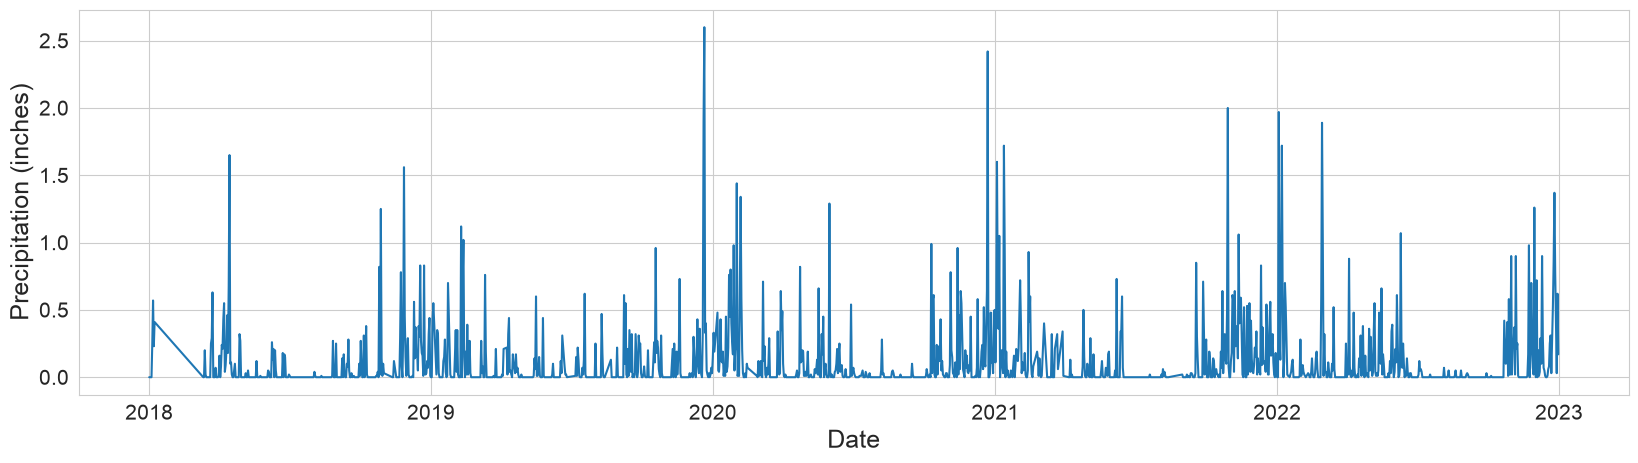

In [26]:
plt.figure(figsize=(20, 5))

sns.lineplot(data=df_seattle, x='DATE', y='PRCP')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

#### Plot the daily precipitation data for Boston.

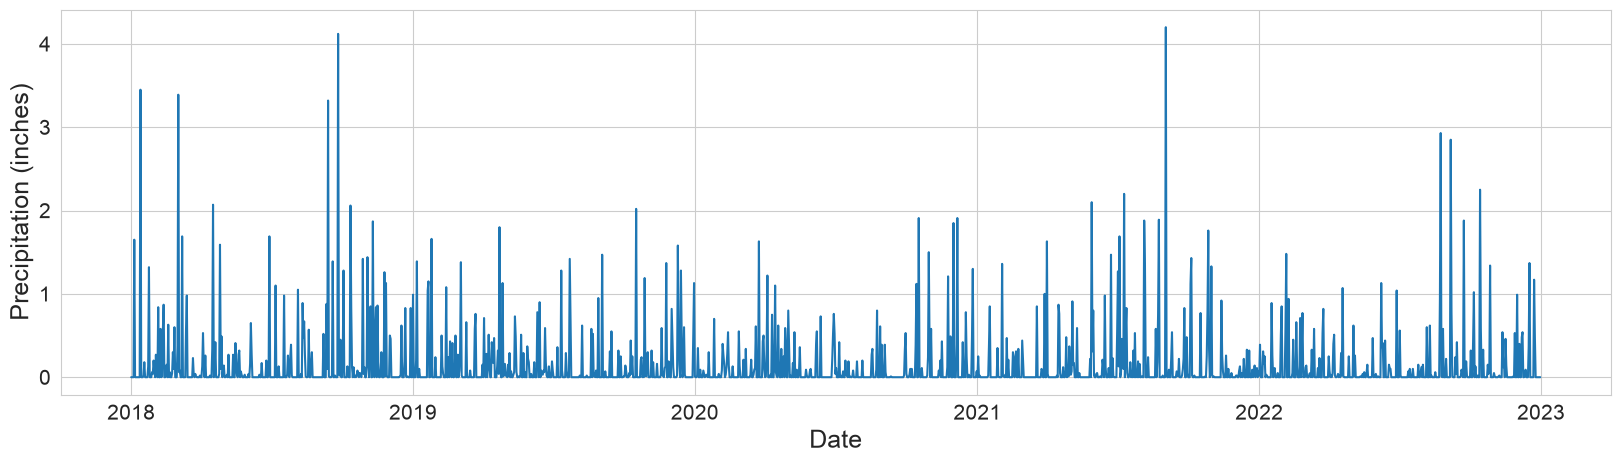

In [27]:
plt.figure(figsize=(20, 5))

sns.lineplot(data=df_boston, x='DATE', y='PRCP')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

### Join data frames keeping DATE and PRCP columns

In [28]:
df_seattle.head(2)

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-01,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-02,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [29]:
df_boston.head(2)

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USC00198368,"NWS BOSTON NORTON, MA US",2018-01-01,0.0,0.0,0.0
1,USC00198368,"NWS BOSTON NORTON, MA US",2018-01-02,0.0,0.0,0.0


In [30]:
df = df_boston[['DATE','PRCP']].merge(df_seattle[['DATE','PRCP']], on='DATE', how='outer')

In [31]:
df.head()

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.00,0.00
4,2018-01-05,1.65,0.25


In [32]:
df.describe()

,DATE,PRCP_x,PRCP_y
count,1826,1826.000000,1636.000000
mean,2020-07-01 12:00:00,0.150953,0.111852
min,2018-01-01 00:00:00,0.000000,0.000000
25%,2019-04-02 06:00:00,0.000000,0.000000
50%,2020-07-01 12:00:00,0.000000,0.010000
75%,2021-09-30 18:00:00,0.090000,0.110000
max,2022-12-31 00:00:00,4.200000,2.600000
std,NaN,0.386289,0.248635


#### Create a tidy data frame with columns for city and precipitation.

In [33]:
# use DATE as the identifier variable
df = pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

In [34]:
df.head()

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.00
3,2018-01-04,PRCP_x,0.00
4,2018-01-05,PRCP_x,1.65


#### Rename columns or values to follow best practices

In [35]:
df.loc[df['city']=='PRCP_x', 'city'] = 'BOS'

In [36]:
df.loc[df['city']=='PRCP_y', 'city'] = 'SEA'

In [37]:
df.head()

,DATE,city,precipitation
0,2018-01-01,BOS,0.00
1,2018-01-02,BOS,0.00
2,2018-01-03,BOS,0.00
3,2018-01-04,BOS,0.00
4,2018-01-05,BOS,1.65


In [38]:
df.tail()

,DATE,city,precipitation
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62
3651,2022-12-31,SEA,0.17


#### Rename the columns to be lowercase using df.rename()

In [39]:
df = df.rename(columns={'DATE': 'date'})

In [40]:
df.head()

,date,city,precipitation
0,2018-01-01,BOS,0.00
1,2018-01-02,BOS,0.00
2,2018-01-03,BOS,0.00
3,2018-01-04,BOS,0.00
4,2018-01-05,BOS,1.65


### Identify and fill in missing values

Data can be missing in multiple manners:

1. Values are NaN in the data frame.

2. Values are not included in the data set.

#### Count the non-null or null values

Determine the number of non-null values in each column.

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[us]
 1   city           3652 non-null   str           
 2   precipitation  3462 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 96.4 KB


In [42]:
df.notna().sum()

date             3652
city             3652
precipitation    3462
dtype: int64

Determine the number of null values in each column.

In [43]:
df.isna().sum()

date               0
city               0
precipitation    190
dtype: int64

Determine the number of null precipitation values for Seattle and Boston.

In [44]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

np.int64(190)

In [45]:
df.loc[df['city'] == 'BOS', 'precipitation'].isna().sum()

np.int64(0)

#### The Boston data set does not have any NaN values of precipitation. Are any dates omitted?

How many data points should we have from 2018 to 2022?

Over 5 years there should be
$$5\times 365 +1 = 1826$$
days. (including the leap year)

The Boston data set is not missing any dates or precipitation values.

#### Impute missing values

We will replace missing values with the mean across years of values on that day.

**Design an algorithm for replacing missing values with the mean across years of values on that day.**

#### Define a column that labels each day by day of the year: 1, 2, 3, ..., 365

In [46]:
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

In [47]:
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,BOS,0.00,1
1,2018-01-02,BOS,0.00,2
2,2018-01-03,BOS,0.00,3
3,2018-01-04,BOS,0.00,4
4,2018-01-05,BOS,1.65,5


#### Compute the mean precipitation for each day in Seattle, averaged across years

In [48]:
mean_day_precipitation = df.loc[
    df['city']=='SEA',
    ['precipitation','day_of_year']
].groupby(
    'day_of_year'
).mean()

In [49]:
mean_day_precipitation

,precipitation
day_of_year,
1,0.052000
2,0.150000
3,0.836000
4,0.370000
5,0.246667
...,...
362,0.120000
363,0.102000
364,0.268000


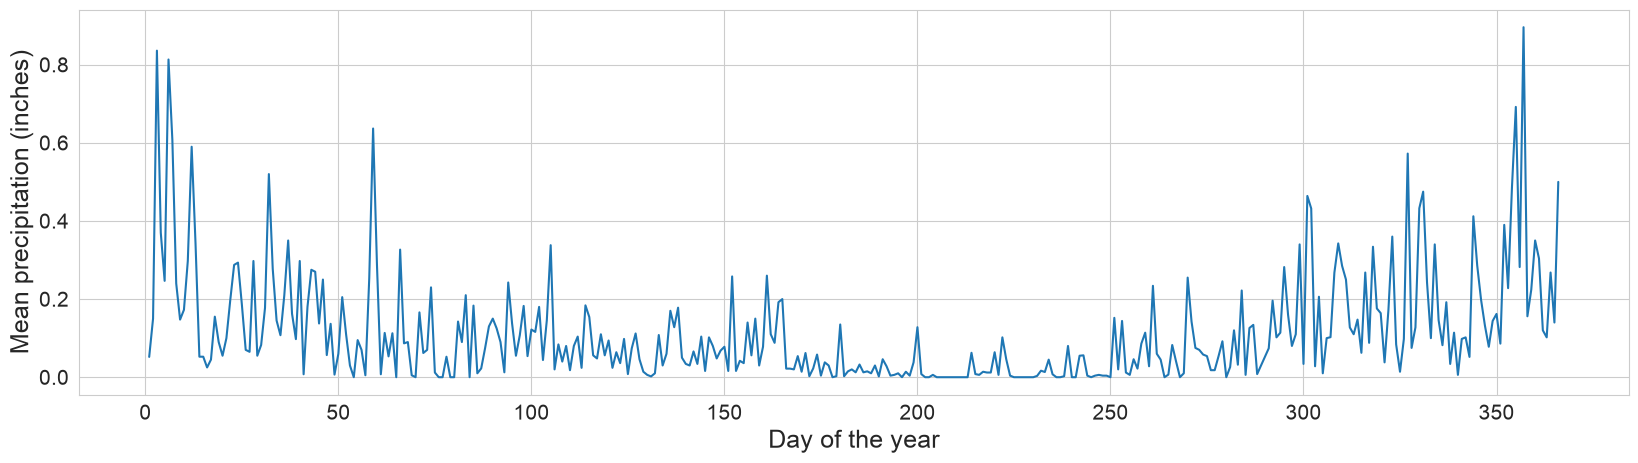

In [50]:
plt.figure(figsize=(20,5))

sns.lineplot(data=mean_day_precipitation, x='day_of_year', y='precipitation')

plt.xlabel('Day of the year', fontsize=18)
plt.ylabel('Mean precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

#### Get the index of each row where precipitation is missing.

In [51]:
indices = np.where(df['precipitation'].isna() == True)[0]

In [52]:
indices

array([1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844,
       1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855,
       1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866,
       1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877,
       1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888,
       1889, 1890, 1891, 1892, 1893, 1894, 1895, 2090, 2131, 2132, 2133,
       2134, 2135, 2136, 2137, 2138, 2139, 2140, 2195, 2196, 2197, 2214,
       2215, 2244, 2245, 2246, 2247, 2248, 2249, 2286, 2287, 2288, 2362,
       2363, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377,
       2417, 2418, 2419, 2420, 2421, 2422, 2423, 2517, 2518, 2519, 2520,
       2521, 2522, 2523, 2524, 2559, 2560, 2561, 2602, 2603, 2604, 2605,
       2606, 2607, 2608, 2609, 2610, 2611, 2612, 2818, 2819, 2820, 2821,
       2822, 2823, 2824, 2825, 2826, 2827, 2972, 2973, 2974, 2975, 2983,
       2984, 2986, 2987, 2988, 3000, 3001, 3004, 30

#### Replace each missing value with the mean on that day

In [53]:
# use for loop to iterate in this array
for index in indices:
    df.loc[index,'precipitation'] = mean_day_precipitation.loc[df.loc[index,'day_of_year']].values[0]

#### Check for missing values in the data frame

In [54]:
df.isna().sum()

date             0
city             0
precipitation    0
day_of_year      0
dtype: int64

After replacing each missing value with the average rainfall for that day, there are no longer any null values.

#### Export the clean .csv file

In [55]:
df.to_csv('clean_seattle_boston_weather.csv', encoding='utf-8-sig', index=False)

# Exploratory data analysis

## Precipitation by day

**Question:** How does daily precipitation differ between Boston and Seattle?

### Plot the daily precipitation data for both Boston and Seattle.

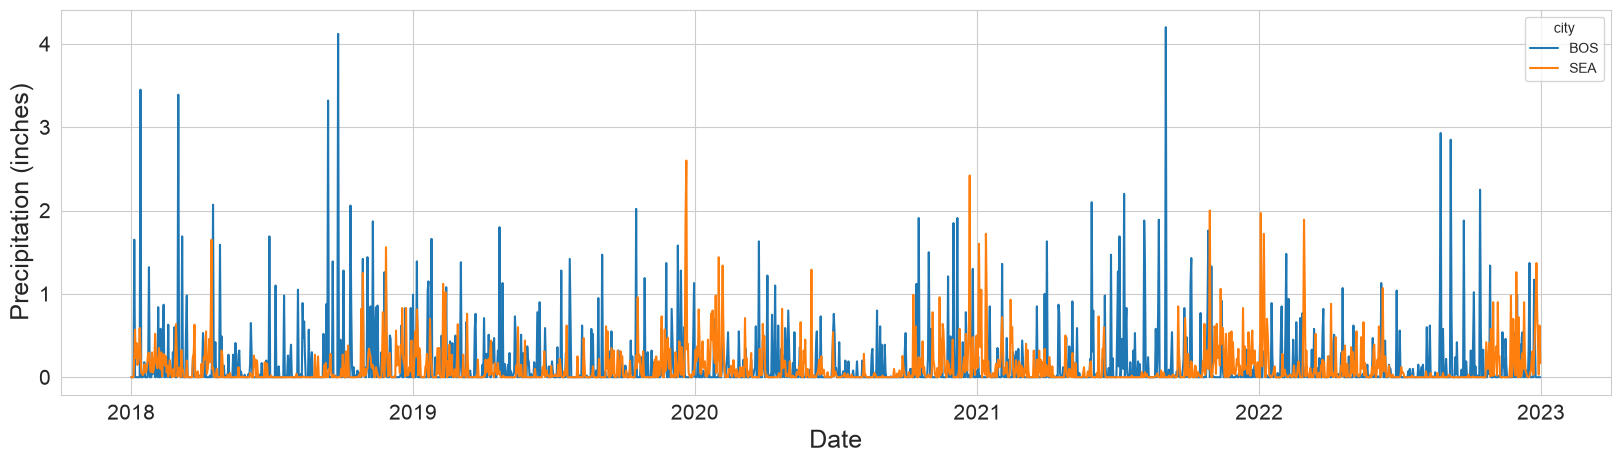

In [56]:
plt.figure(figsize=(20,5))

sns.lineplot(data=df, x='date', y='precipitation', hue='city')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

Daily precipitation varies considerably in both Boston and Seattle from 2018 to 2022. There are more extreme precipitation in Boston, with several peaks above 3 inches and a maximum above 4 inches, while Seattle's peak is below 3 inches. Most days in both cities have little or no precipitation. Overall, Seattle’s precipitation is generally lower.

### Compute basic numerical summaries for precipitation in each city

In [57]:
df[['city','precipitation']].groupby('city').describe()

precipitation                                               
             count      mean       std  min  25%   50%   75%  max
city                                                             
BOS         1826.0  0.150953  0.386289  0.0  0.0  0.00  0.09  4.2
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.6

The average precipitation of Boston is higher than Seattle (0.15 vs 0.11). The median of each is very small and slightly higher in Seattle (0.01 vs 0.00). Boston has the higher maximum precipitation than Seattle (4.2 vs 2.6).

### Compute mean precipitation values averaged over all days

In [58]:
df[['city', 'precipitation']].groupby('city').mean()

,precipitation
city,
BOS,0.150953
SEA,0.113270


#### Show the values as a bar graph

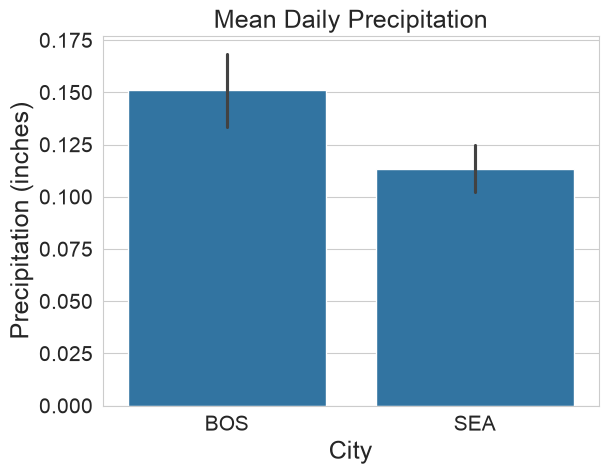

In [59]:
sns.barplot(data=df, x='city', y='precipitation')

plt.xlabel('City', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)
plt.title('Mean Daily Precipitation', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

#### What does the errorbar represent?

In [60]:
sns.barplot?

Signature:
sns.barplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    order=None,
    hue_order=None,
    estimator='mean',
    errorbar=('ci', 95),
    n_boot=1000,
    seed=None,
    units=None,
    weights=None,
    orient=None,
    color=None,
    palette=None,
    saturation=0.75,
    fill=True,
    hue_norm=None,
    width=0.8,
    dodge='auto',
    gap=0,
    log_scale=None,
    native_scale=False,
    formatter=None,
    legend='auto',
    capsize=0,
    err_kws=None,
    ci=<deprecated>,
    errcolor=<deprecated>,
    errwidth=<deprecated>,
    ax=None,
    **kwargs,
)
Docstring:
Show point estimates and errors as rectangular bars.

A bar plot represents an aggregate or statistical estimate for a numeric
variable with the height of each rectangle and indicates the uncertainty
around that estimate using an error bar. Bar plots include 0 in the
axis range, and they are a good choice when 0 is a meaningful value
for the variable to take.

See the :ref:`tutorial 

It tells us errorbar=('ci', 95) which means that error bar is a confidence interval with 95%.

## Precipitation by month

**Question:** How do precipitation patterns vary by month in Boston and Seattle?

### Add a column to the data frame with the number of the month

In [61]:
df['month'] = pd.DatetimeIndex(df['date']).month

In [62]:
df.head()

,date,city,precipitation,day_of_year,month
0,2018-01-01,BOS,0.00,1,1
1,2018-01-02,BOS,0.00,2,1
2,2018-01-03,BOS,0.00,3,1
3,2018-01-04,BOS,0.00,4,1
4,2018-01-05,BOS,1.65,5,1


In [63]:
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

### Plot the distribution of precipitation amounts each month using boxplots

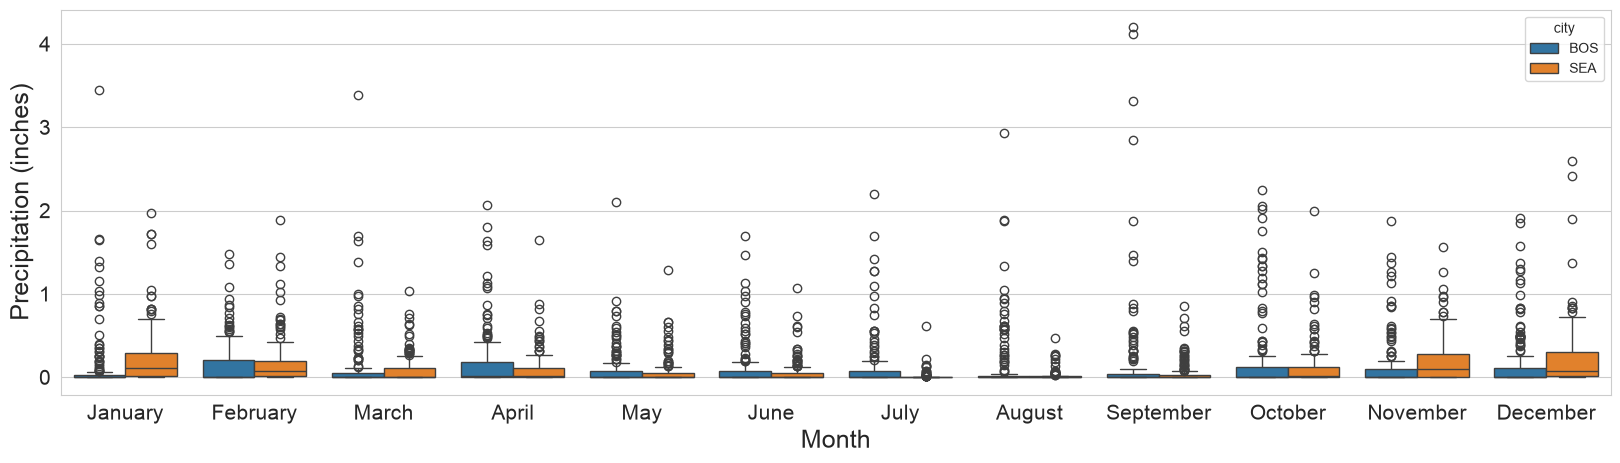

In [64]:
plt.figure(figsize=(20,5))

sns.boxplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

# Get month names and set as x-axis tick labels
import calendar
month_names = list(calendar.month_name[1:]) 
plt.xticks(ticks=range(12), labels=month_names)

plt.show()

Seattle shows higher precipitation in the winter and lower precipitation in the summer, while Boston’s precipitation is more evenly distributed throughout the year. Both cities contain many high-value outliers.

#### Orient the plot horizontally

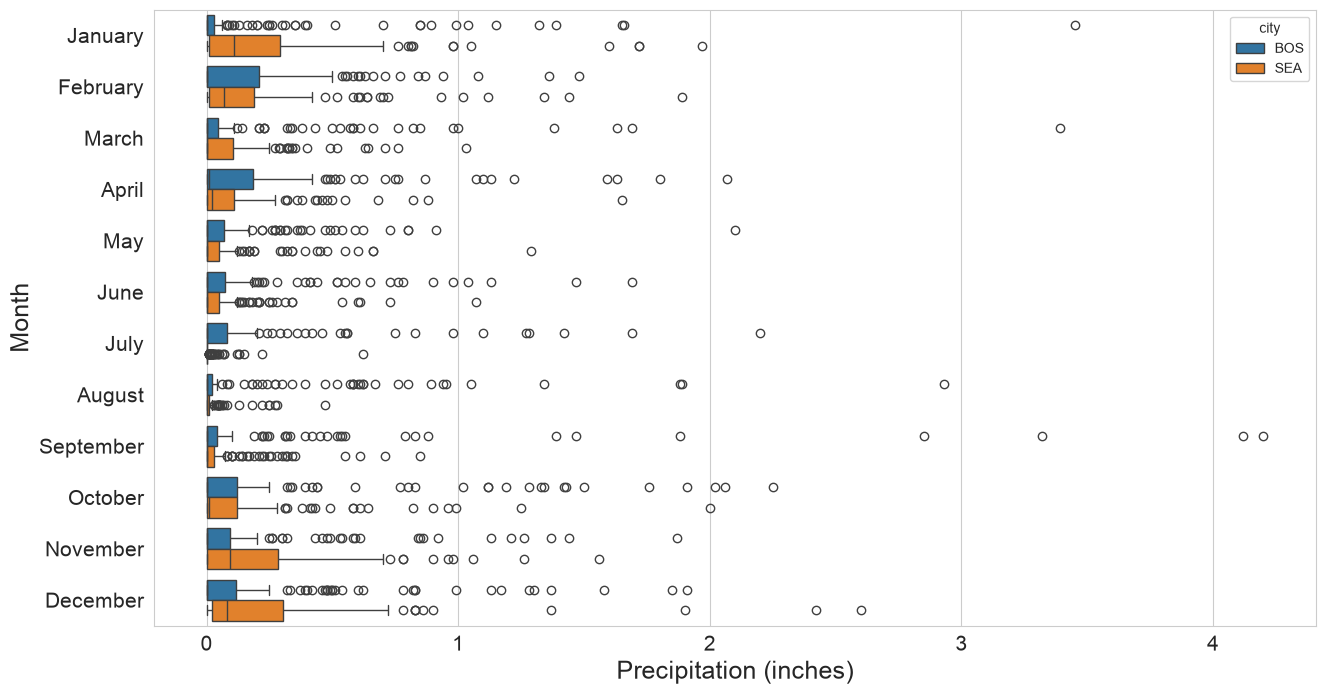

In [65]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df, x='precipitation', y='month', hue='city', orient='h')

plt.xlabel('Precipitation (inches)', fontsize=18)
plt.ylabel('Month', fontsize=18)

plt.tick_params(labelsize=15)

plt.yticks(ticks=range(12), labels=month_names)

plt.show()

This horizontal plot makes it easier to see. Seattle has much more rain in November, December and January than Boston. However, Seattle is drier during summer. Boston’s precipitation is more consistent across the year. Boston has several of the most extreme events, including precipitation above 4 inches in September.

#### Zoom in on the precipitation axis

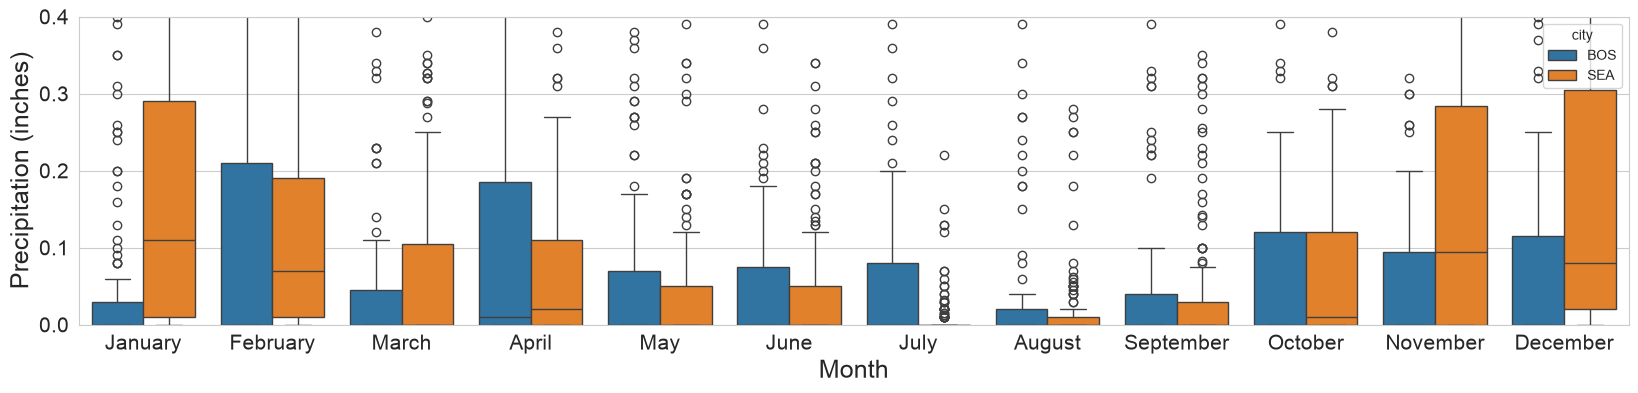

In [66]:
plt.figure(figsize=(20,4))

sns.boxplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.ylim(0, 0.4)

plt.show()

After zooming in, the seasonal pattern in Seattle becomes clearer, with higher daily precipitation during the winter and lower precipitation during the summer.

### Plot the mean precipitation each month

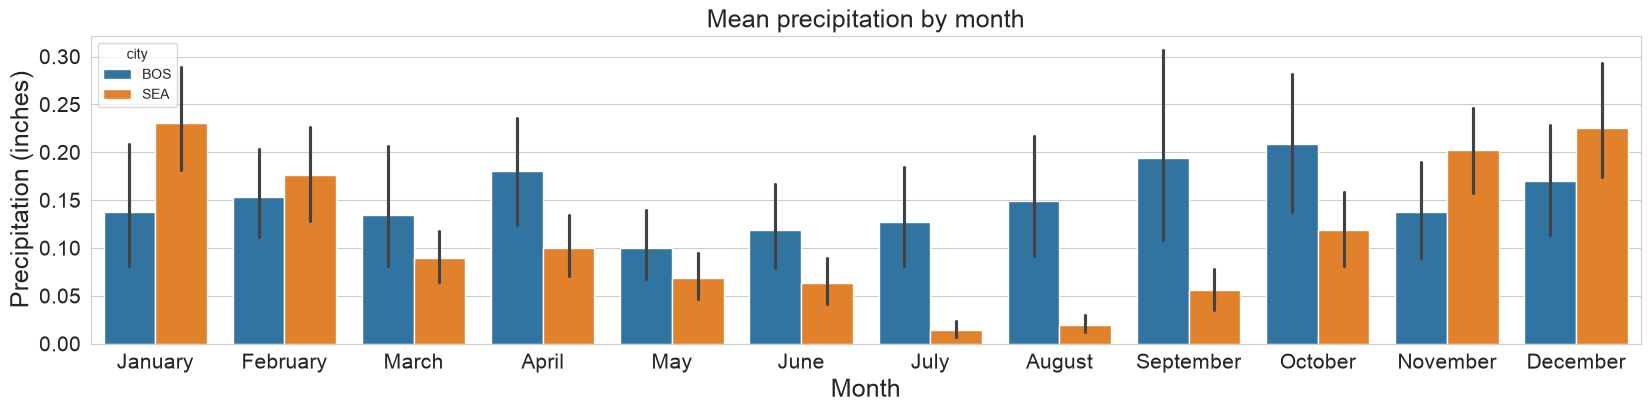

In [67]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)
plt.title('Mean precipitation by month', fontsize=18)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.savefig("/Users/anhtuyet15999/Projects/weather/reports/mean_precipitation_by_month.png", dpi=300, bbox_inches='tight')

plt.show()

#### Compute the mean precipitation each month

In [68]:
df[['month', 'precipitation', 'city']].groupby(['city', 'month']).mean()

precipitation
city month               
BOS  1           0.137935
     2           0.153050
     3           0.134645
     4           0.180400
     5           0.100516
     6           0.118933
     7           0.127290
     8           0.148581
     9           0.194400
     10          0.208516
     11          0.137800
     12          0.170452
SEA  1           0.230742
     2           0.176472
     3           0.089075
     4           0.100483
     5           0.069161
     6           0.063167
     7           0.013984
     8           0.019995
     9           0.055622
     10          0.118452
     11          0.201867
     12          0.224903

Boston’s mean monthly precipitation is relatively consistent throughout the year, ranging from about 0.10 to 0.21 inches per day. Its highest average occurs in October (0.21 inches). 
In contrast, in Seattle, the mean precipitation is highest in January (0.23 inches) and December (0.22 inches), but drops sharply during the summer, reaching its lowest level in July (0.014 inches). 
Seattle has higher mean precipitation than Boston from November through February, while Boston has higher averages from March through October.

## Precipitation by year

**Question:** How does total annual precipitation compare between Boston and Seattle from 2018 to 2022?

### Add a column to the data frame with the number of the year

In [69]:
df['year'] = pd.DatetimeIndex(df['date']).year

In [70]:
df.head()

,date,city,precipitation,day_of_year,month,year
0,2018-01-01,BOS,0.00,1,1,2018
1,2018-01-02,BOS,0.00,2,1,2018
2,2018-01-03,BOS,0.00,3,1,2018
3,2018-01-04,BOS,0.00,4,1,2018
4,2018-01-05,BOS,1.65,5,1,2018


In [71]:
df.tail()

,date,city,precipitation,day_of_year,month,year
3647,2022-12-27,SEA,0.78,361,12,2022
3648,2022-12-28,SEA,0.40,362,12,2022
3649,2022-12-29,SEA,0.03,363,12,2022
3650,2022-12-30,SEA,0.62,364,12,2022
3651,2022-12-31,SEA,0.17,365,12,2022


### Compute the total precipitation per year

In [72]:
yearly_precipitation = df.groupby([df['city'],df['year']])['precipitation'].sum().reset_index()

In [73]:
yearly_precipitation

,city,year,precipitation
0,BOS,2018,70.500000
1,BOS,2019,55.100000
2,BOS,2020,43.660000
3,BOS,2021,56.230000
4,BOS,2022,50.150000
5,SEA,2018,37.244167
6,SEA,2019,38.653333
7,SEA,2020,43.221667
8,SEA,2021,44.434167
9,SEA,2022,43.278333


### Plot the total precipitation per year

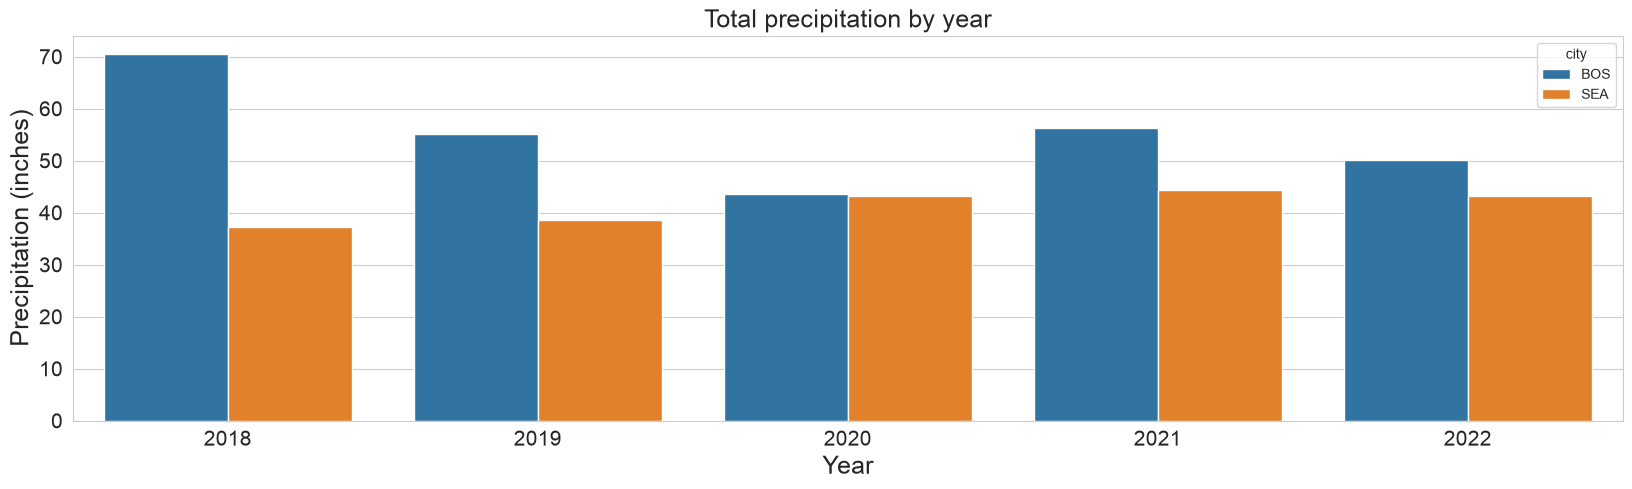

In [74]:
plt.figure(figsize=(20,5))

sns.barplot(data=yearly_precipitation, x='year', y='precipitation', hue='city')

plt.xlabel("Year", fontsize=18)
plt.ylabel("Precipitation (inches)", fontsize=18)
plt.title("Total precipitation by year", fontsize=18)

plt.tick_params(labelsize=15)

plt.savefig("/Users/anhtuyet15999/Projects/weather/reports/total_precipitation_by_year.png", dpi=300, bbox_inches='tight')

plt.show()

Surprisingly, Boston had almost twice as much total precipitation as Seattle in 2018, while the two cities had very similar totals in 2020. Overall, Boston had higher total annual precipitation than Seattle from 2018 to 2022. Boston also had greater variability in total annual precipitation (43.66 inches - 70.5 inches), whereas Seattle's total annual precipitation was relatively stable (37.24 inches - 44.43 inches).

## Proportion of days with any precipitation

**Question:** How often does precipitation occur in each city, and how does its frequency vary by month?

### Add a variable to the data frame that indicates whether there was any precipitation

In [75]:
df['any_precipitation'] = df['precipitation'] > 0

In [76]:
df.head()

,date,city,precipitation,day_of_year,month,year,any_precipitation
0,2018-01-01,BOS,0.00,1,1,2018,False
1,2018-01-02,BOS,0.00,2,1,2018,False
2,2018-01-03,BOS,0.00,3,1,2018,False
3,2018-01-04,BOS,0.00,4,1,2018,False
4,2018-01-05,BOS,1.65,5,1,2018,True


### Plot the proportion of days with any precipitation over the 5 years

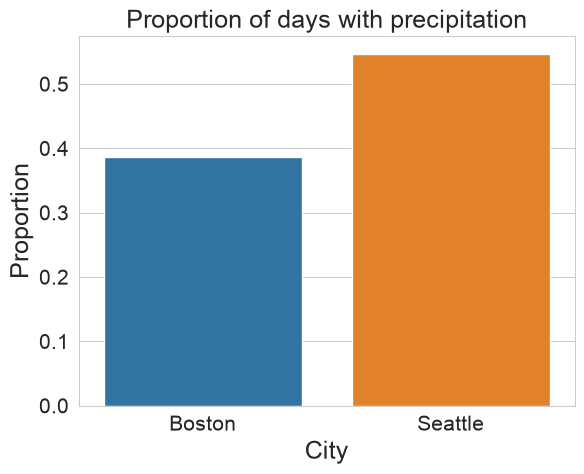

In [77]:
sns.barplot(data=df, x='city', y='any_precipitation', hue='city', errorbar=None)

plt.xlabel('City', fontsize=18)
plt.ylabel('Proportion', fontsize=18)
plt.title('Proportion of days with precipitation', fontsize=18)

plt.xticks([0, 1], ['Boston', 'Seattle'])

plt.tick_params(labelsize=15)

plt.savefig("/Users/anhtuyet15999/Projects/weather/reports/proportion_days_with_precipitation.png", dpi=300, bbox_inches='tight')

plt.show()

We have more than half of the days where there was some measured precipitation in Seattle and about 40% of the days where there was precipitation in Boston. Therefore, Seattle has precipitation more frequently than Boston.

### Plot the proportion of days with precipitation each month

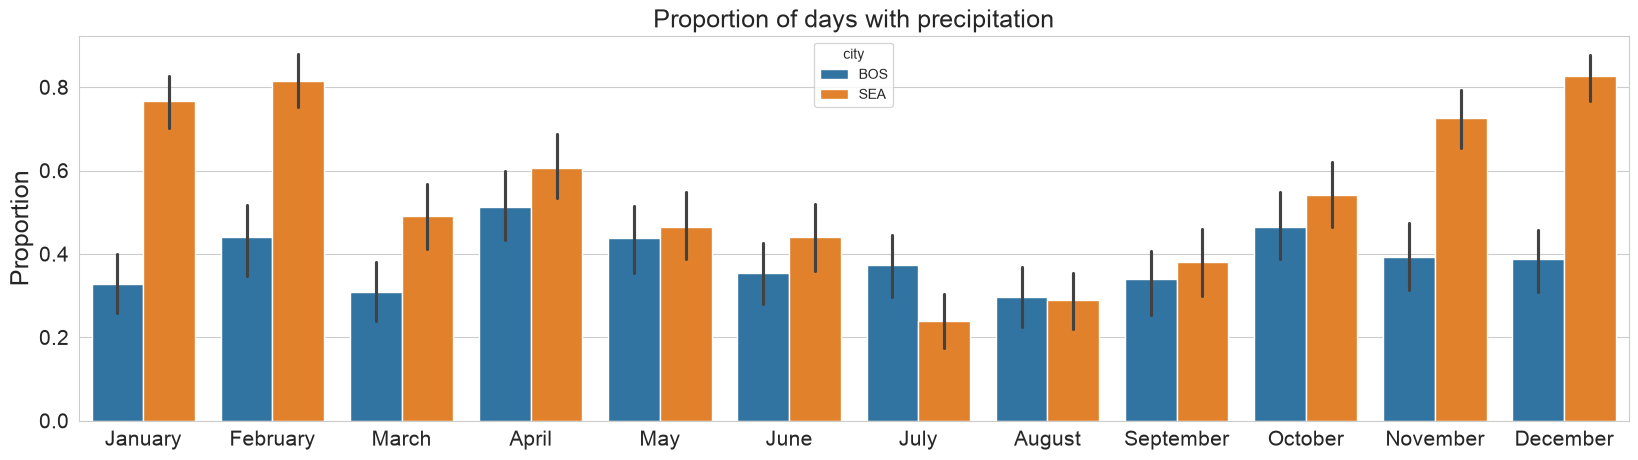

In [78]:
plt.figure(figsize=(20,5))

sns.barplot(data=df, x='month', y='any_precipitation', hue='city')

plt.xlabel(None)
plt.ylabel('Proportion', fontsize=18)
plt.title('Proportion of days with precipitation', fontsize=18)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.show()

There is a difference in winter months and summer months. There is much more often precipitation during the winter in Seattle than Boston. During the winter months, precipitation occurs on roughly 70–80% of days in Seattle, compared with about 30–45% in Boston.

## Precipitation on days with precipitation

**Question:** When precipitation occurs, how much precipitation does each city receive on average?

### Compute the mean precipitation on days with precipitation

In [79]:
rainy_days = df[df['precipitation'] > 0]

In [80]:
rainy_days[['city', 'precipitation']].groupby('city').mean()

,precipitation
city,
BOS,0.390979
SEA,0.207039


### Plot the mean precipitation on days with precipitation

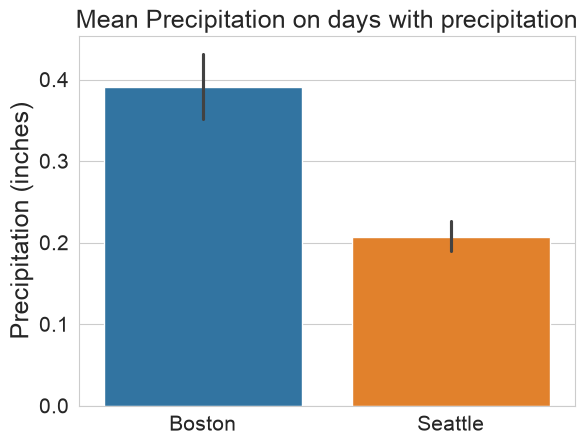

In [81]:
sns.barplot(data=rainy_days, x='city', y='precipitation', hue='city')

plt.title("Mean Precipitation on days with precipitation", fontsize=18)
plt.xlabel(None)
plt.ylabel("Precipitation (inches)", fontsize=18)

plt.xticks([0, 1], ['Boston', 'Seattle'])

plt.tick_params(labelsize=15)

plt.savefig("/Users/anhtuyet15999/Projects/weather/reports/mean_precipitation_days_with_precipitation.png", dpi=300, bbox_inches='tight')

plt.show()

Although Seattle has precipitation more frequently, Boston has more precipitation on days when it rains. On rainy days, Boston averages about 0.39 inches, compared with about 0.21 inches in Seattle.

# Statistical Analysis

## Differences in mean precipitation by month

**Question:** Are the differences in mean precipitation between Boston and Seattle statistically significant each month?

### Perform a statistical test for difference in the mean precipitation each month between the cities

\begin{aligned}
H_0 &: \mu_{\mathrm{Seattle,January}} = \mu_{\mathrm{Boston,January}} \\
H_a &: \mu_{\mathrm{Seattle,January}} \neq \mu_{\mathrm{Boston,January}} \\
&\vdots \\
H_0 &: \mu_{\mathrm{Seattle,December}} = \mu_{\mathrm{Boston,December}} \\
H_a &: \mu_{\mathrm{Seattle,December}} \neq \mu_{\mathrm{Boston,December}}
\end{aligned}


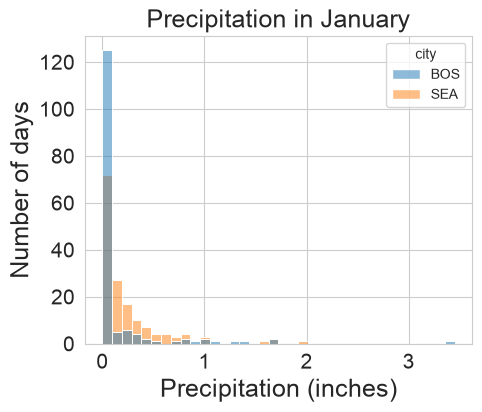

In [82]:
plt.figure(figsize=(5,4))

sns.histplot(data = df.loc[df['month'] == 1], x='precipitation', hue='city')

plt.xlabel('Precipitation (inches)', fontsize=18)
plt.ylabel('Number of days', fontsize=18)
plt.title('Precipitation in January', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

The January precipitation distributions are strongly right-skewed, with many days having little or no precipitation and a smaller number of days with relatively high precipitation.

In [83]:
from scipy import stats

In [84]:
significance_level = 0.05
significantly_different = np.zeros(12)

# Perform t-test for each month
for month in range(1,13):
    #Get precipitation data for Seattle and Boston for the current month
    sea_data = df.loc[(df['city'] == 'SEA') & (df['month'] == month), 'precipitation']
    bos_data = df.loc[(df['city'] == 'BOS') & (df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, bos_data, equal_var=False)

    if p_value < significance_level:
        significantly_different[month-1] = 1

    print(f"Month {month}: ")
    print(f" t_statistic = {t_statistic:.2f}")
    print(f" p_value t test = {p_value:.3f}")
    print("-" * 20)

Month 1: 
 t_statistic = 2.17
 p_value t test = 0.031
--------------------
Month 2: 
 t_statistic = 0.68
 p_value t test = 0.496
--------------------
Month 3: 
 t_statistic = -1.34
 p_value t test = 0.182
--------------------
Month 4: 
 t_statistic = -2.36
 p_value t test = 0.019
--------------------
Month 5: 
 t_statistic = -1.34
 p_value t test = 0.180
--------------------
Month 6: 
 t_statistic = -2.16
 p_value t test = 0.032
--------------------
Month 7: 
 t_statistic = -4.25
 p_value t test = 0.000
--------------------
Month 8: 
 t_statistic = -4.05
 p_value t test = 0.000
--------------------
Month 9: 
 t_statistic = -2.61
 p_value t test = 0.010
--------------------
Month 10: 
 t_statistic = -2.09
 p_value t test = 0.037
--------------------
Month 11: 
 t_statistic = 1.85
 p_value t test = 0.065
--------------------
Month 12: 
 t_statistic = 1.28
 p_value t test = 0.200
--------------------


### Plot the mean precipitation each month with a star for significant differences

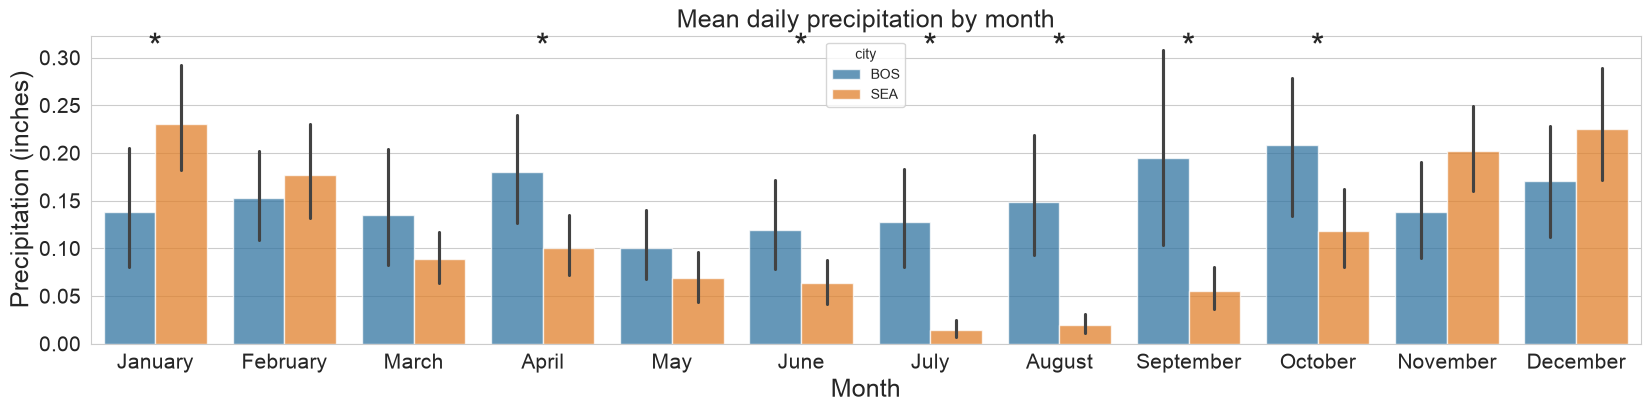

In [85]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='precipitation', hue='city', alpha=0.75)

plt.ylabel('Precipitation (inches)', fontsize=18)
plt.xlabel('Month', fontsize=18)
plt.title('Mean daily precipitation by month', fontsize=18)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months
for month in range(12):
    if significantly_different[month] == 1:
        plt.text(month, 0.3, '*', ha='center', fontsize=25)

plt.show()

This shows that there are significant differences in January, April, June, July, August, September and October.

Therefore, at the 5% significance level, we reject the null hypothesis for January, April, June, July, August, September, and October. This provides evidence that mean daily precipitation differs significantly between Boston and Seattle during these months. For the remaining months, we fail to reject the null hypothesis.

## Differences in the proportion of days with precipitation by month

**Question:** Are the differences in the proportion of days with precipitation between Boston and Seattle statistically significant each month?

### Perform a statistical test for difference in the proportion of days with any precipitation each month between the cities

\begin{aligned}
H_0 &: p_{\mathrm{Seattle,January}} = p_{\mathrm{Boston,January}} \\
H_a &: p_{\mathrm{Seattle,January}} \neq p_{\mathrm{Boston,January}} \\
&\vdots \\
H_0 &: p_{\mathrm{Seattle,December}} = p_{\mathrm{Boston,December}} \\
H_a &: p_{\mathrm{Seattle,December}} \neq p_{\mathrm{Boston,December}}
\end{aligned}

In [86]:
from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different_proportion = np.zeros(12)

# Perform z-test for each month
for month in range(1,13):
    # Create a contingency table for Seattle and Boston for the current month:
    contingency_table = pd.crosstab(
        df.loc[df['month'] == month, 'city'], df.loc[df['month'] == month, 'any_precipitation']
    )
    
    # Calculate the number of True values (days with precipitation) for each city:
    days_with_precipitation = contingency_table[True]

    # Calculate the total number of days for each city:
    total_counts = contingency_table.sum(axis=1)

    # Hypothesis test
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, nobs=total_counts, alternative='two-sided'
    )

    if p_value < significance_level:
        significantly_different_proportion[month-1] = 1

    print(f"Month {month}: ")
    print(f" z_statistic = {zstat:.2f}")
    print(f" p_value z test = {p_value:.3f}")
    print("-" * 20)

Month 1: 
 z_statistic = -7.76
 p_value z test = 0.000
--------------------
Month 2: 
 z_statistic = -6.53
 p_value z test = 0.000
--------------------
Month 3: 
 z_statistic = -3.25
 p_value z test = 0.001
--------------------
Month 4: 
 z_statistic = -1.63
 p_value z test = 0.103
--------------------
Month 5: 
 z_statistic = -0.46
 p_value z test = 0.648
--------------------
Month 6: 
 z_statistic = -1.53
 p_value z test = 0.125
--------------------
Month 7: 
 z_statistic = 2.59
 p_value z test = 0.010
--------------------
Month 8: 
 z_statistic = 0.12
 p_value z test = 0.901
--------------------
Month 9: 
 z_statistic = -0.72
 p_value z test = 0.470
--------------------
Month 10: 
 z_statistic = -1.36
 p_value z test = 0.173
--------------------
Month 11: 
 z_statistic = -5.82
 p_value z test = 0.000
--------------------
Month 12: 
 z_statistic = -7.91
 p_value z test = 0.000
--------------------


### Plot the proportion of days with any precipitation each month with a star for significant differences

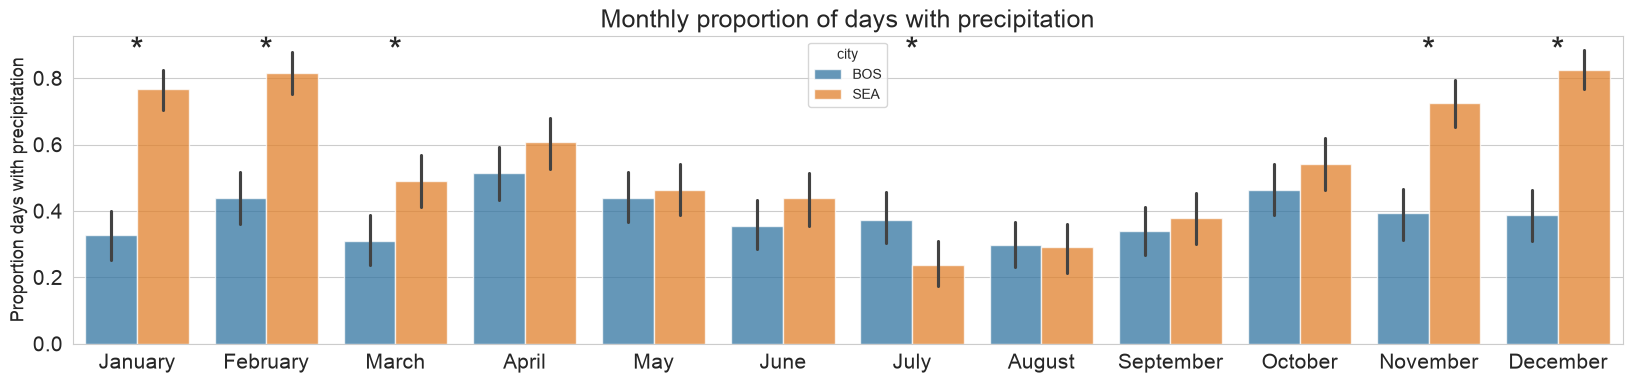

In [87]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='any_precipitation', hue='city', alpha=0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.title('Monthly proportion of days with precipitation', fontsize=18)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months
for month in range(12):
    if significantly_different_proportion[month] == 1:
        plt.text(month, 0.85, '*', ha='center', fontsize=25)

plt.show()

This shows that there are significant differences in January, February, March, July, November and December.

Therefore, at the 5% significance level, we reject the null hypothesis for January, February, March, July, November, and December. This provides evidence that the proportion of days with precipitation differs significantly between Boston and Seattle during these months. For the remaining months, we fail to reject the null hypothesis.

# Conclusion

Overall, whether it rains more in Seattle than Boston depends on how “more rain” is defined. 
Seattle has precipitation more frequently, with precipitation occurring on more than half of the days compared with about 40% of days in Boston. Seattle also shows stronger seasonality, with particularly frequent precipitation during the winter months. 
However, Boston has more precipitation on days when precipitation occurs, with the average precipitation of about 0.39 inches compared with 0.21 inches in Seattle. Boston also has a higher overall mean daily precipitation and generally higher annual precipitation totals. 
Therefore, Seattle can be considered rainier in terms of frequency, while Boston tends to receive heavier and greater amounts of precipitation. The statistical tests show that these differences are significant during several months of the year.